# Spaceship Titanic — a guided EDA

**EDA** stands for *exploratory data analysis*: the part of a data project where you look at the
data and try to understand it, before you build anything that makes predictions.

This notebook is written for someone new to data. Every section says **why** we are running a
piece of code, not just what it does. Jargon is defined the first time it appears, and there is
a glossary at the bottom.

---

## The problem

The Spaceship Titanic hit a spacetime anomaly. Some passengers were **transported** to another
dimension; others were not. We have records for 8,693 passengers where we know what happened,
and 4,277 where we do not.

Our job: work out *what kind of passenger got transported*.

That is a **binary classification** problem — for each passenger the answer is one of two
things, `True` or `False`.

## How to use this notebook

- Run cells top to bottom with `Shift + Enter`.
- Every number here has been checked against the analysis scripts in `src/`. If you change a
  cell and a number moves, that is you learning something, not a bug.
- The three sections marked **★ HIGHLIGHT** are the ones worth slowing down on. They are where
  the dataset stops being a spreadsheet and starts being interesting.

## What you will learn

| Section | Idea |
|---|---|
| 1 | Why you always establish a **baseline** before believing any result |
| 3 | Why "2% missing" can quietly cost you a quarter of your data |
| 4 | How to find features **hidden inside text columns** |
| 5 ★ | Spotting a **deterministic rule**, and why "missing" is not always "unknown" |
| 6 ★ | **Confounding** — the reason a naive comparison can point the wrong way |
| 7 ★ | How an **ID column** can turn out to be the strongest predictor in the file |
| 9 | **Uncertainty** — when a difference is real and when it is noise |

## 0. Setup

We import the project's own helper modules rather than writing everything from scratch.

- `src/load.py` reads the CSV files and does the parsing work. It is the **single source of
  truth** — if we each wrote our own version of the parsing, our numbers would drift apart.
- `src/viz.py` holds the chart styling, the colour palette, and two statistics helpers we will
  meet later.

`load()` gives back three tables:

| name | what it is |
|---|---|
| `train` | 8,693 passengers **with** the answer (`Transported`) |
| `test` | 4,277 passengers **without** it — this is what Kaggle scores you on |
| `combined` | both stacked together, 12,970 rows |

**The rule to remember:** anything that involves the answer must use `train` only, because
`test` has no answer column. Facts about *structure* — how many values are missing, how cabins
are numbered — can use `combined`, which gives us more rows to look at. We will say which one
we are using every time.

In [1]:
import sys
from pathlib import Path

# Make the project's src/ importable from inside notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import load as L
import viz

# viz.py sets the "Agg" backend (for scripts that only write files).
# In a notebook we want charts to appear inline as well, so we save AND display.
from IPython.display import Image, display

(ROOT / "figures" / "nb").mkdir(parents=True, exist_ok=True)

def show(fig, name, title=None, subtitle=None):
    """Save a figure to figures/nb/ and display it inline."""
    path = viz.save(fig, f"nb/{name}", title, subtitle)
    display(Image(str(path)))

print("python     :", sys.version.split()[0])
print("pandas     :", pd.__version__)
print("project    :", ROOT)

python     : 3.12.14
pandas     : 3.0.5
project    : /home/user/spaceship-titanic


In [2]:
train, test, combined = L.load()

print(f"train    : {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"test     : {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"combined : {combined.shape[0]:,} rows")
print()
print("test has no answer column:", L.TARGET not in test.columns)

train    : 8,693 rows x 27 columns
test     : 4,277 rows x 26 columns
combined : 12,970 rows

test has no answer column: True


## 1. The baseline — the number every other number is judged against

Before looking at a single feature, ask: **how often does the thing we are predicting happen at
all?**

This is the **baseline** (also called the *marginal rate*). It matters because it is the score
you would get by not thinking at all — just guessing the more common answer every time. Any
feature we find has to beat it, or it is worthless.

In [3]:
rate = train[L.TARGET].mean()
print(f"Transported = True : {train[L.TARGET].sum():,} of {len(train):,}")
print(f"baseline rate      : {rate:.1%}")
print()
print("So a model that guesses 'True' for everyone scores about 50.4%.")
print("Remember this number. Every rate below is read against it.")

Transported = True : 4,378 of 8,693
baseline rate      : 50.4%

So a model that guesses 'True' for everyone scores about 50.4%.
Remember this number. Every rate below is read against it.


**50.4%.** That is an unusually balanced dataset — real-world problems are often 95%/5%, which
brings its own headaches. Here we are spared that, which is one reason this competition is a
good first one.

From now on, when you see a rate like "65%", the interesting part is not the 65 — it is the
**+15 points above 50.4%**.

> **Reading tip: "pp" means percentage points.** Going from 50% to 65% is a rise of 15
> *percentage points*, not 15 percent. Keeping these separate saves a lot of confusion later.

## 2. First look at the raw table

Three commands you will use on literally every dataset you ever open:

- `.head()` — show the first few rows, so you can see what a record actually looks like
- `.info()` — column names, data types, and how many values are present
- `.describe()` — min / max / mean / quartiles for the numeric columns

Look at these before forming any opinion.

In [4]:
train.head(5)[["PassengerId", "HomePlanet", "CryoSleep", "Cabin", "Destination",
               "Age", "VIP", "RoomService", "FoodCourt", "Name", "Transported"]]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,Willy Santantines,True


In [5]:
# Only the original columns — load.py adds some of its own, which we meet in section 4.
original = ["PassengerId", "HomePlanet", "CryoSleep", "Cabin", "Destination", "Age", "VIP",
            "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Name", "Transported"]
train[original].info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [6]:
train[["Age"] + L.SPEND_COLS].describe().round(1)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.0,8512.0,8510.0,8485.0,8510.0,8505.0
mean,28.8,224.7,458.1,173.7,311.1,304.9
std,14.5,666.7,1611.5,604.7,1136.7,1145.7
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,19.0,0.0,0.0,0.0,0.0,0.0
50%,27.0,0.0,0.0,0.0,0.0,0.0
75%,38.0,47.0,76.0,27.0,59.0,46.0
max,79.0,14327.0,29813.0,23492.0,22408.0,24133.0


Two things are already visible in `.describe()`:

1. **The spending columns are wildly skewed.** Look at `RoomService`: the median (the `50%` row)
   is 0, but the maximum is over 14,000. Most people spend nothing; a few spend enormous amounts.
   An average is a poor summary of a column that looks like this.
2. **`Age` has a minimum of 0.** Is that a real newborn, or is 0 being used as a code for
   "unknown"? This is a genuinely important question and it has a real answer — we check it in
   section 8.

## 3. Missing data — the trap that eats a quarter of your rows

Real datasets have gaps. The beginner's instinct is to check "what percentage of this column is
missing?", see a small number, and move on. Let us do that first, then see why it misleads.

In [7]:
miss = pd.DataFrame({
    "missing": combined[original[:-1]].isna().sum(),
    "pct": combined[original[:-1]].isna().mean() * 100,
}).sort_values("pct", ascending=False).round(2)
miss

,missing,pct
CryoSleep,310,2.39
ShoppingMall,306,2.36
Cabin,299,2.31
VIP,296,2.28
Name,294,2.27
FoodCourt,289,2.23
HomePlanet,288,2.22
Spa,284,2.19
Destination,274,2.11
Age,270,2.08


Every column sits between **2.03% and 2.39%** missing. That is a spread of 0.36 percentage
points across twelve columns — suspiciously even. It looks like the gaps were *injected at
random, one cell at a time*, rather than arising from some real-world process (like "rich
passengers refused to give their age").

Each column on its own looks harmless. Now ask the question that actually matters.

In [8]:
nulls_per_row = combined[original[:-1]].isna().sum(axis=1)
any_null = (nulls_per_row > 0).sum()

print(f"rows with at least one missing value: {any_null:,} of {len(combined):,} "
      f"({any_null / len(combined):.1%})")
print()
print("distribution of missing values per row:")
print(nulls_per_row.value_counts().sort_index().to_string())
print()
print(f"--> dropna() would throw away {any_null / len(combined):.1%} of the data.")

rows with at least one missing value: 3,083 of 12,970 (23.8%)

distribution of missing values per row:
0    9887
1    2746
2     316
3      21

--> dropna() would throw away 23.8% of the data.


### The lesson

**2% per column becomes 24% per row.** Twelve columns each missing ~2% independently means
roughly one row in four is touched by *something*.

`df.dropna()` — the most common beginner reflex — would delete a quarter of this dataset.

The good news: most of those gaps are **recoverable**, not lost. Sections 5 and 8 show that many
"missing" values here can be worked out with certainty from other columns. That is a much better
outcome than either dropping the row or filling the gap with a column average.

> **Why filling with the average is often wrong:** it invents a plausible-looking value that
> nobody actually had, and it shrinks the column's real variation. Only reach for it when you
> genuinely have nothing better. Here, we usually do have something better.

## 4. The headline: three of these "columns" are not columns

This is the single most important idea in the whole dataset, so it gets its own section.

Look again at three fields:

| column | example value |
|---|---|
| `PassengerId` | `0003_01` |
| `Cabin` | `A/0/P` |
| `Name` | `Maham Ofracculy` |

`pd.read_csv` reads all three as plain text. A model can do nothing with them, so the standard
first move is to drop them as "identifiers".

**That would throw away most of the signal in this file.** Each one is several fields glued
together:

- `PassengerId` is `gggg_pp` — a **travel group** number and a position within it. People who
  booked together share the `gggg` part. It is not an ID at all; it is a *social link*.
- `Cabin` is `deck/number/side` — a **physical location** on the ship.
- `Name` is `first surname` — and the surname is a **family**.

`src/load.py` does this decoding for us. Let us see what it produced.

In [9]:
cols = ["PassengerId", "Group", "MemberNo", "Cabin", "Deck", "CabinNum", "Side",
        "Name", "Surname", "GroupSize"]
train[cols].head(8)

,PassengerId,Group,MemberNo,Cabin,Deck,CabinNum,Side,Name,Surname,GroupSize
0,0001_01,1,1,B/0/P,B,0,P,Maham Ofracculy,Ofracculy,1
1,0002_01,2,1,F/0/S,F,0,S,Juanna Vines,Vines,1
2,0003_01,3,1,A/0/S,A,0,S,Altark Susent,Susent,2
3,0003_02,3,2,A/0/S,A,0,S,Solam Susent,Susent,2
4,0004_01,4,1,F/1/S,F,1,S,Willy Santantines,Santantines,1
5,0005_01,5,1,F/0/P,F,0,P,Sandie Hinetthews,Hinetthews,1
6,0006_01,6,1,F/2/S,F,2,S,Billex Jacostaffey,Jacostaffey,2
7,0006_02,6,2,G/0/S,G,0,S,Candra Jacostaffey,Jacostaffey,2


In [10]:
print(f"distinct travel groups : {combined['Group'].nunique():,}")
print(f"distinct surnames      : {combined['Surname'].nunique():,}")
print(f"distinct decks         : {sorted(combined['Deck'].dropna().unique())}")
print(f"cabin sides            : {sorted(combined['Side'].dropna().unique())}")
print()
solo = (combined["GroupSize"] == 1).mean()
print(f"passengers travelling alone : {solo:.1%}")
print(f"passengers in a group       : {1 - solo:.1%}")

distinct travel groups : 9,280
distinct surnames      : 2,406
distinct decks         : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
cabin sides            : ['P', 'S']

passengers travelling alone : 55.1%
passengers in a group       : 44.9%


Three text columns just became eight usable features. This is called **feature engineering**,
and on this dataset it is worth more than any choice of model you make afterwards.

> **Habit worth forming:** before dropping a column because it "looks like an ID", print a few
> values and ask whether it has internal structure. Dates, postcodes, product SKUs, IP
> addresses and order numbers are all commonly several fields in a trench coat.

We will use `Group` in section 7 and `Deck`/`Side` in section 8.

## 5. ★ HIGHLIGHT 1 — a rule with no exceptions

`CryoSleep` records whether a passenger elected to be frozen for the voyage. Frozen passengers
were confined to their cabins.

That suggests a hypothesis: **a frozen passenger cannot spend money.** Let us test it — not on a
sample, not approximately, but on every single row of both files.

> **Why check both `train` and `test` here?** This is a question about the *structure* of the
> data, not about the answer we are predicting. Structural claims get stronger with more rows,
> and `test` rows are perfectly good evidence for them.

In [11]:
frozen = combined[combined["CryoSleep"] == True]
awake  = combined[combined["CryoSleep"] == False]

print(f"frozen passengers : {len(frozen):,}")
print(f"awake passengers  : {len(awake):,}")
print()
print("Any frozen passenger with a nonzero charge on any service?")
violations = (frozen[L.SPEND_COLS].fillna(0) > 0).any(axis=1).sum()
print(f"  violations: {violations}")
print()

# How many chances did the rule actually have to fail? Only frozen passengers
# can break a rule about frozen passengers, and only cells that were recorded.
cells_all = frozen[L.SPEND_COLS].size
cells_obs = int(frozen[L.SPEND_COLS].notna().sum().sum())
print(f"spend cells belonging to frozen passengers: {cells_all:,}")
print(f"  ...of which actually recorded           : {cells_obs:,}")
print(f"  ...blank (so not a test either way)     : {cells_all - cells_obs:,}")
print()
for c in L.SPEND_COLS:
    mx = frozen[c].max()
    print(f"  {c:14s} max charge among frozen passengers = {mx}")

frozen passengers : 4,581
awake passengers  : 8,079

Any frozen passenger with a nonzero charge on any service?
  violations: 0

spend cells belonging to frozen passengers: 22,905
  ...of which actually recorded           : 22,374
  ...blank (so not a test either way)     : 531

  RoomService    max charge among frozen passengers = 0.0
  FoodCourt      max charge among frozen passengers = 0.0
  ShoppingMall   max charge among frozen passengers = 0.0
  Spa            max charge among frozen passengers = 0.0
  VRDeck         max charge among frozen passengers = 0.0


**Zero violations in 22,374 observed spend cells.** Every one of the 4,581 frozen passengers
spent exactly 0 on all five services, without exception.

Notice the denominator, because it is the honest one. The file has 12,970 rows, but a rule of the
form *"frozen implies zero"* can only be broken by a **frozen** passenger — the 8,079 awake ones
and the 310 whose `CryoSleep` we do not know were never able to break it. That leaves 4,581 rows
and 22,905 spend cells, of which 22,374 were actually recorded. So the rule had 22,374 chances to
fail and took none of them.

> **The habit:** when you say "no exceptions in N", make sure N counts the cases that *could*
> have been an exception. Quoting all 12,970 rows here would inflate the evidence about threefold
> — and would be quoting rows that were never at risk.

That is not a trend or a correlation — it is a **deterministic rule**, a hard constraint built
into how this data was generated. Deterministic rules are gold, because they let you fill in
missing values *with certainty* rather than by guessing.

Two consequences fall straight out of it:

In [12]:
# Consequence 1: NaN spend under CryoSleep=True is a KNOWN ZERO, not an unknown.
cryo_nan = frozen[L.SPEND_COLS].isna().sum().sum()
print(f"1. Blank spend cells belonging to frozen passengers : {cryo_nan}")
print("   These are not gaps. We KNOW the value is 0. Filling them with the")
print("   column median would insert spending that provably did not happen.")
print()

# Consequence 2: the rule runs backwards.
unknown_cryo = combined[combined["CryoSleep"].isna()]
spent = (unknown_cryo[L.SPEND_COLS].fillna(0) > 0).any(axis=1)
print(f"2. Passengers whose CryoSleep is missing          : {len(unknown_cryo)}")
print(f"   ...of whom spent money, so were certainly AWAKE : {spent.sum()} "
      f"({spent.mean():.1%})")
print("   No model required. The rule recovers these values outright.")

1. Blank spend cells belonging to frozen passengers : 531
   These are not gaps. We KNOW the value is 0. Filling them with the
   column median would insert spending that provably did not happen.

2. Passengers whose CryoSleep is missing          : 310
   ...of whom spent money, so were certainly AWAKE : 174 (56.1%)
   No model required. The rule recovers these values outright.


### And does it actually predict anything?

A rule is only interesting if the column it involves matters. `CryoSleep` turns out to be the
strongest single raw column in the dataset.

In [13]:
cryo_rates = viz.rate_table(train, "CryoSleep")

# Relabel the True/False index to words. A boolean index is awkward to slice:
# pandas reads a LIST of booleans as a mask, not as a set of labels.
cryo_rates.index = [{True: "frozen", False: "awake"}.get(i, "unknown (missing)")
                    for i in cryo_rates.index]

cryo_rates[["n", "k", "rate", "lo", "hi"]].round(4)

,n,k,rate,lo,hi
awake,5439,1789,0.3289,0.3166,0.3415
frozen,3037,2483,0.8176,0.8034,0.8309
unknown (missing),217,106,0.4885,0.4228,0.5546


  -> figures/nb/05_cryosleep_rule_and_payoff.png


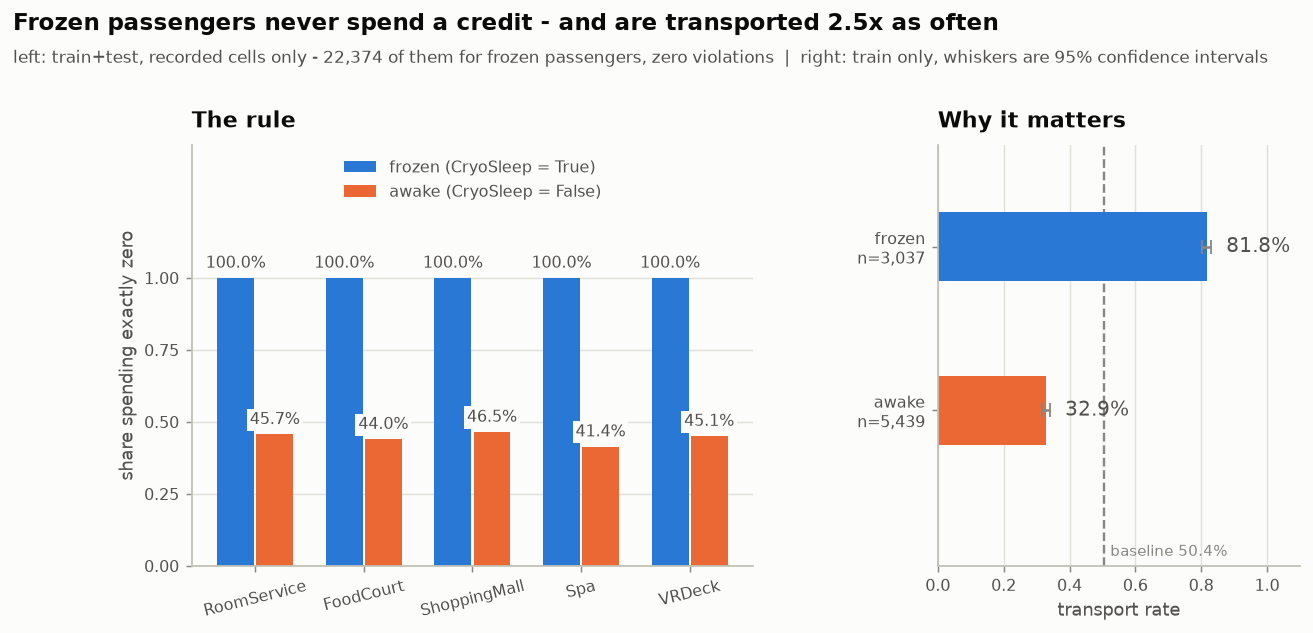

In [14]:
# ---- HIGHLIGHT CHART 1 -----------------------------------------------------
# Left panel  : the rule        (share of passengers spending exactly zero)
# Right panel : why it matters  (transport rate, frozen vs awake)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2),
                               gridspec_kw={"width_ratios": [1.55, 1]})

# --- left: the rule ---
# Both series count RECORDED cells only, and identically. An earlier version
# used .fillna(0) on the frozen bars and a bare == 0 on the awake ones, which
# read a blank cell as a zero for one group and as a non-zero for the other --
# the same NaN treated two ways in a single chart, worth about 1pp on the
# awake bars. The frozen 100% is genuine either way.
zero_frozen = [frozen[c].dropna().eq(0).mean() for c in L.SPEND_COLS]
zero_awake  = [awake[c].dropna().eq(0).mean() for c in L.SPEND_COLS]
x, w = np.arange(len(L.SPEND_COLS)), 0.34
# A small gap between the two fills, so a wide label cannot sit on its neighbour.
bf = axL.bar(x - 0.18, zero_frozen, w, color=viz.SERIES[0], label="frozen (CryoSleep = True)")
ba = axL.bar(x + 0.18, zero_awake,  w, color=viz.SERIES[1], label="awake (CryoSleep = False)")

def label_clear(ax, bars, vals):
    """Direct labels with a surface-coloured backing, so a label that is wider
    than its bar stays readable over whatever sits behind it."""
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.022, f"{v:.1%}",
                ha="center", va="bottom", fontsize=9, color=viz.INK_SECONDARY,
                bbox=dict(facecolor=viz.SURFACE, edgecolor="none", pad=1.6), zorder=6)

label_clear(axL, bf, zero_frozen)
label_clear(axL, ba, zero_awake)
axL.set_xticks(x, L.SPEND_COLS, rotation=14)
axL.set_ylim(0, 1.46)
axL.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
axL.set_ylabel("share spending exactly zero")
axL.set_title("The rule", loc="left", pad=10)
axL.legend(loc="upper center", ncols=1)
viz.clean(axL)

# --- right: why it matters ---
rt = cryo_rates.reindex(["awake", "frozen"])
y = np.arange(2)
axR.barh(y, rt["rate"], 0.42, color=[viz.SERIES[1], viz.SERIES[0]], zorder=2)
axR.errorbar(rt["rate"], y, xerr=[rt["rate"] - rt["lo"], rt["hi"] - rt["rate"]],
             fmt="none", ecolor=viz.INK_MUTED, capsize=4, lw=1.4, zorder=3)
for yi, (r, hi) in enumerate(zip(rt["rate"], rt["hi"])):
    axR.text(hi + 0.045, yi, f"{r:.1%}", va="center", ha="left",
             fontsize=11, color=viz.INK_SECONDARY)
axR.set_yticks(y, [f"{lab}\nn={n:,}" for lab, n in zip(rt.index, rt["n"])])
axR.set_xlim(0, 1.10)
axR.set_ylim(-0.95, 1.62)
axR.set_xlabel("transport rate")
axR.set_title("Why it matters", loc="left", pad=10)
viz.clean(axR, which="x")

# Baseline labelled at the BOTTOM of the panel, clear of the title and the bars.
axR.axvline(rate, color=viz.INK_MUTED, linestyle="--", lw=1.3, zorder=1)
axR.text(rate + 0.02, 0.015, f"baseline {rate:.1%}", transform=axR.get_xaxis_transform(),
         va="bottom", ha="left", fontsize=8.5, color=viz.INK_MUTED)

fig.subplots_adjust(wspace=0.40)
show(fig, "05_cryosleep_rule_and_payoff",
     "Frozen passengers never spend a credit - and are transported 2.5x as often",
     "left: train+test, recorded cells only - 22,374 of them for frozen passengers, zero violations"
     "  |  right: train only, whiskers are 95% confidence intervals")

### How to read this chart

**Left panel.** Each pair of bars is one service. The blue bar is frozen passengers, the orange
bar is awake ones. All five blue bars sit at exactly 100% — every frozen passenger spent zero on
every service. The orange bars sit around 40–46%, because plenty of awake passengers also happen
not to use a given service. The contrast between a flat 100% and a scattered 40-something is
what tells you the first one is a *rule* and the second is just *behaviour*.

**Right panel.** The payoff. Frozen passengers were transported **81.8%** of the time; awake
passengers only **32.9%**. The dashed line is our 50.4% baseline from section 1, so frozen sits
far above it and awake far below.

The little horizontal whiskers on the bars are **confidence intervals** — a visual statement of
how precise each estimate is. They are narrow here because both groups have thousands of
passengers. In section 9 we will meet a group where they are not narrow at all.

**Watch out though.** Because being awake is so strongly tied to being transported, *anything
else that only awake people do* will inherit that signal. That is exactly the trap the next
section is about.

## 6. ★ HIGHLIGHT 2 — confounding, the most useful idea in this notebook

There are five things a passenger could spend money on: `RoomService`, `FoodCourt`,
`ShoppingMall`, `Spa`, `VRDeck`.

A very reasonable first move is to add them into one `TotalSpend` column and ask "do big
spenders get transported more or less?" Let us do the naive version first and see what it says.

In [15]:
naive = []
for c in L.SPEND_COLS:
    sub = train[train[c].notna()]
    spent = sub[c] > 0
    naive.append({
        "service": c,
        "rate_spent": sub.loc[spent, L.TARGET].mean(),
        "rate_zero":  sub.loc[~spent, L.TARGET].mean(),
    })
naive = pd.DataFrame(naive)
naive["gap_pp"] = (naive["rate_spent"] - naive["rate_zero"]) * 100
naive.round(3)

,service,rate_spent,rate_zero,gap_pp
0,RoomService,0.260,0.633,-37.335
1,FoodCourt,0.345,0.591,-24.546
2,ShoppingMall,0.317,0.599,-28.160
3,Spa,0.277,0.639,-36.172
4,VRDeck,0.275,0.628,-35.261


Every single service has a **negative** gap. Spending money on anything appears to lower your
chance of being transported. The obvious conclusion: "spending is bad, roll it into one column,
move on."

**That conclusion is wrong, and section 5 already told us why.**

Spending money requires being awake. Awake passengers are transported only 32.9% of the time.
So *any* behaviour that only awake people can do will look negative — not because the behaviour
matters, but because it is a marker for being awake.

This is **confounding**: a third variable (`CryoSleep`) sitting behind both the thing we are
measuring and the outcome, creating an association that is not really about spending at all.

### The fix: compare like with like

The cure is to **stratify** — look only within a group where the confounder is held constant.
Here that means: *among awake passengers only*, does spending on a given service still matter?

Everyone in this comparison is awake, so being awake can no longer explain any difference we
find.

In [16]:
aw = train[train["CryoSleep"] == False]

honest = []
for c in L.SPEND_COLS:
    sub = aw[aw[c].notna()]
    m = sub[c] > 0
    p1, n1 = sub.loc[m, L.TARGET].mean(),  int(m.sum())
    p0, n0 = sub.loc[~m, L.TARGET].mean(), int((~m).sum())
    se = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)   # standard error of the gap
    honest.append({"service": c, "rate_spent": p1, "rate_zero": p0,
                   "gap_pp": (p1 - p0) * 100, "se_pp": se * 100,
                   "z": (p1 - p0) / se})
honest = pd.DataFrame(honest)
honest["verdict"] = np.where(honest["z"].abs() <= 1.96, "flat",
                      np.where(honest["gap_pp"] > 0, "raises", "lowers"))

print(f"awake passengers only: n={len(aw):,}, their baseline rate = {aw[L.TARGET].mean():.1%}")
honest.round(3)

awake passengers only: n=5,439, their baseline rate = 32.9%


,service,rate_spent,rate_zero,gap_pp,se_pp,z,verdict
0,RoomService,0.260,0.411,-15.065,1.287,-11.710,lowers
1,FoodCourt,0.346,0.308,3.756,1.291,2.910,raises
2,ShoppingMall,0.318,0.342,-2.409,1.290,-1.867,flat
3,Spa,0.278,0.401,-12.295,1.315,-9.349,lowers
4,VRDeck,0.276,0.394,-11.725,1.297,-9.039,lowers


The picture changes completely.

- `RoomService`, `Spa`, `VRDeck` stay clearly **negative**, and in fact get stronger.
- `FoodCourt` **flips sign** — spending there now *raises* your chance of being transported.
- `ShoppingMall` goes **flat** — its gap is small enough that we cannot distinguish it from zero.

The `z` column is how many standard errors the gap sits from zero. A rough rule: **|z| above
about 2 means the gap is unlikely to be chance; below 2, we cannot call a direction.**
`ShoppingMall` has z = −1.87, which is under the bar — so we call it flat rather than negative.

Read that carefully, because the wording matters more than it looks. "We cannot call a direction"
is **not** the same as "there is no effect". `ShoppingMall`'s interval is [−4.9pp, +0.1pp], which
is almost entirely on the negative side — the data simply has not pinned it down well enough to
say so. Absence of evidence is not evidence of absence, and the 2.0 threshold is a convention we
chose, not a fact about the world.

Let us draw the before-and-after.

  -> figures/nb/06_confounding_dumbbell.png


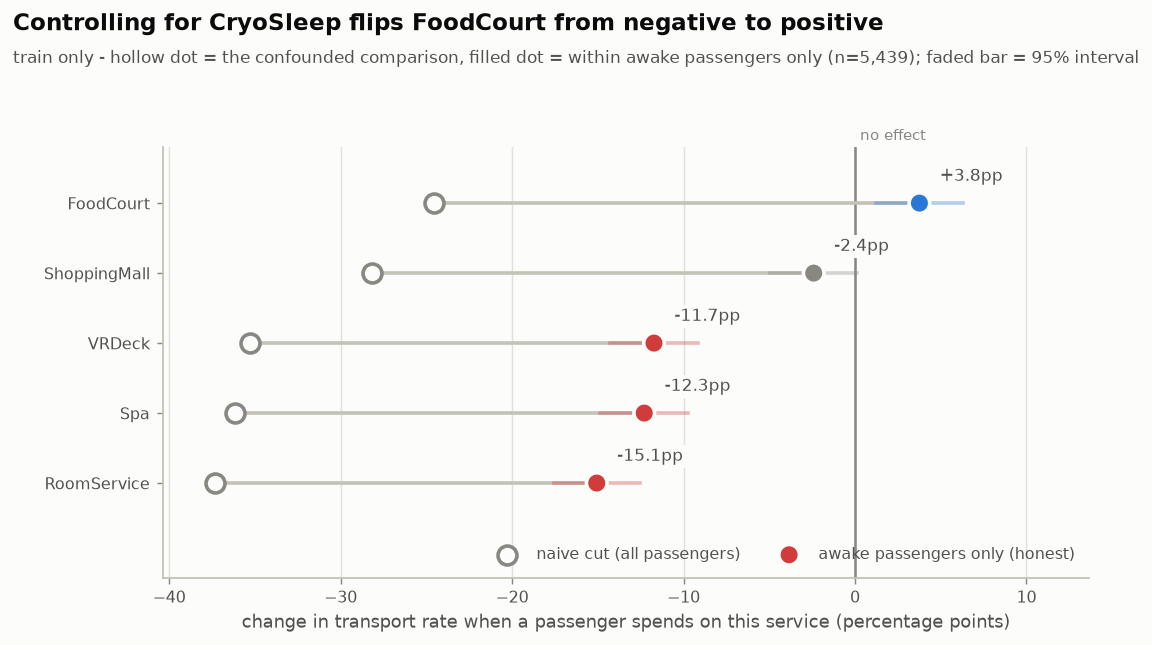

In [17]:
# ---- HIGHLIGHT CHART 2 -----------------------------------------------------
# A "dumbbell": for each service, the naive gap and the honest gap, connected.
# The whole point of the chart is which dots cross the zero line.

both = honest.merge(naive[["service", "gap_pp"]], on="service", suffixes=("", "_naive"))
both = both.sort_values("gap_pp")

VERDICT_COLOR = {"lowers": "#d03b3b", "raises": "#2a78d6", "flat": viz.INK_MUTED}

fig, ax = plt.subplots(figsize=(9.2, 4.3))
y = np.arange(len(both))

ax.axvline(0, color=viz.INK_MUTED, lw=1.4, zorder=1)
ax.text(0, 1.008, " no effect", transform=ax.get_xaxis_transform(),
        va="bottom", ha="left", fontsize=8.5, color=viz.INK_MUTED)

for yi, r in zip(y, both.itertuples()):
    ax.plot([r.gap_pp_naive, r.gap_pp], [yi, yi], color=viz.BASELINE, lw=2, zorder=2)
    # 95% interval on the honest estimate
    ax.plot([r.gap_pp - 1.96 * r.se_pp, r.gap_pp + 1.96 * r.se_pp], [yi, yi],
            color=VERDICT_COLOR[r.verdict], lw=2, alpha=0.35, zorder=3)

ax.scatter(both["gap_pp_naive"], y, s=110, facecolor=viz.SURFACE,
           edgecolor=viz.INK_MUTED, linewidth=2, zorder=4, label="naive cut (all passengers)")
ax.scatter(both["gap_pp"], y, s=130,
           color=[VERDICT_COLOR[v] for v in both["verdict"]],
           edgecolor=viz.SURFACE, linewidth=2, zorder=5,
           label="awake passengers only (honest)")

# The x range has to hold the NAIVE dots too -- they run out to -37.3pp, and
# an axis that stops at -22 clips every one of them off the edge, leaving five
# grey connectors running to nowhere and a hollow dot in the legend that
# appears nowhere in the plot. The confounded starting point is half of what
# this chart is for, so derive the limits from the data rather than typing them.
lo = min(both["gap_pp_naive"].min(), (both["gap_pp"] - 1.96 * both["se_pp"]).min())
hi = max(both["gap_pp"].max() + 1.96 * both["se_pp"].max(), 0)
pad = 0.07 * (hi - lo)
xlo, xhi = lo - pad, hi + 2.4 * pad   # extra room on the right for the labels

# Label offsets are in DATA units, so they have to scale with the range too --
# a fixed 1.6 was tuned for a 32pp-wide axis and would sit on the dot here.
off_pp = 0.022 * (xhi - xlo)
for yi, r in zip(y, both.itertuples()):
    off = off_pp if r.gap_pp >= r.gap_pp_naive else -off_pp
    # Surface backing, as on highlight chart 1: ShoppingMall's label sits right
    # on top of the zero rule, and a value that has to be read through a line
    # is a value the reader has to work for.
    ax.text(r.gap_pp + off, yi + 0.26, f"{r.gap_pp:+.1f}pp",
            va="bottom", ha="left" if off > 0 else "right",
            fontsize=9.5, color=viz.INK_SECONDARY, zorder=6,
            bbox=dict(facecolor=viz.SURFACE, edgecolor="none", pad=1.6))

ax.set_yticks(y, both["service"])
ax.set_xlabel("change in transport rate when a passenger spends on this service "
              "(percentage points)")
ax.set_xlim(xlo, xhi)
# One extra row of headroom at the bottom, so the legend has somewhere to sit
# that is not on top of the RoomService dumbbell.
ax.set_ylim(-1.35, len(both) - 0.2)
ax.legend(loc="lower right", ncols=2)
viz.clean(ax, which="x")

show(fig, "06_confounding_dumbbell",
     "Controlling for CryoSleep flips FoodCourt from negative to positive",
     "train only - hollow dot = the confounded comparison, filled dot = within awake passengers "
     "only (n=5,439); faded bar = 95% interval")

### How to read this chart

Each row is one service. Read left to right as "bad for you" to "good for you".

- The **hollow dot** is the naive answer — all passengers lumped together. Every hollow dot sits
  to the left of the zero line, which is the misleading result we started with.
- The **filled dot** is the honest answer — awake passengers only.
- The **grey bar between them** is how much the confounder was distorting things.
- The **faded coloured bar** around each filled dot is its 95% interval: the range of values
  consistent with the data. If that bar touches the zero line, we cannot claim a direction.

Now the punchline is visual. `FoodCourt` is the one row whose filled dot has crossed to the
**right** of zero. `ShoppingMall`'s interval still overlaps zero, so it stays grey and we say
nothing about its direction.

### Why this matters practically

If you had summed the five columns into one `TotalSpend`, you would have averaged a strong
negative (`RoomService`, −15.1pp), a genuine positive (`FoodCourt`, +3.8pp) and a nothing
(`ShoppingMall`) into a single mush, and destroyed the distinction.

The three negative ones — room service, spa, VR deck — are all **private, in-cabin** services.
`FoodCourt` is the one you have to leave your cabin for. Whether that is the real mechanism we
cannot prove from this data alone, but it is a sensible story and it matches four of the five
services.

**Four of five, not five of five** — and it is worth naming the one that does not fit.
`ShoppingMall` is also somewhere you have to leave your cabin for, so the story predicts it
should be positive like `FoodCourt`. It is flat. A story that covers most of the evidence is
still useful, but apply this notebook's own habit to it: ask what else is different, and say out
loud which case you could not explain. A tidy story that quietly drops its counterexample is how
a plausible mechanism turns into a wrong one.

> **The transferable lesson:** when a comparison gives you a result, ask *"what else is
> different between these two groups?"* If you can name something, stratify on it and look
> again. This one habit will catch more mistakes than any modelling technique.

## 7. ★ HIGHLIGHT 3 — the ID column that predicts the answer

Back to `PassengerId` = `gggg_pp`. We established in section 4 that `gggg` is a travel group.

Now the real question: **if you know what happened to someone's travelling companion, does that
tell you anything about them?**

To answer it we take every pair of people inside the same unit and count how often their fates
agree. We use the project's own `pair_concordance` function so the numbers match `FINDINGS.md`
exactly.

In [18]:
import importlib.util

spec = importlib.util.spec_from_file_location("groups_mod", ROOT / "src" / "02_groups.py")
groups_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(groups_mod)

# An exact-cabin key, so we can compare "same cabin" with "same group" and "same surname".
train2 = train.copy()
train2["CabinKey"] = train2["Cabin"]

units = {"travel group": "Group", "surname (family)": "Surname", "exact cabin": "CabinKey"}
rows = []
for label, key in units.items():
    r = groups_mod.pair_concordance(train2, key)
    rows.append({"unit": label, "pairs": r["pairs"], "people": r["members"],
                 "mate_T_given_ego_T": r["p_mate_t_given_ego_t"],
                 "mate_T_given_ego_F": r["p_mate_t_given_ego_f"]})
conc = pd.DataFrame(rows)
conc["swing_pp"] = (conc["mate_T_given_ego_T"] - conc["mate_T_given_ego_F"]) * 100
conc.round(4)

,unit,pairs,people,mate_T_given_ego_T,mate_T_given_ego_F,swing_pp
0,travel group,4501,3888,0.6074,0.5148,9.2639
1,surname (family),18804,8111,0.5161,0.4700,4.6171
2,exact cabin,3323,3067,0.6500,0.5456,10.4407


Read the first row like this: among people who share a travel group, if I tell you one member
was transported, the chance their companion was also transported is **60.7%**. If I tell you the
member was *not* transported, it drops to **51.5%**.

Against a 50.4% baseline, that is a real, usable shift — from a column most people delete.

Two things worth noticing straight away:

- **Sharing a group is a stronger link than sharing a surname.** Sharing a cabin *looks*
  stronger still — but hold that thought. The chart below draws the uncertainty around every
  one of these six numbers, and once the uncertainty is visible, cabin and travel group
  turn out to be too close together to tell apart.
- **Fate is correlated, not determined.** 60.7% is a long way from 95%. Groups were *not*
  transported wholesale, which is a much more interesting dataset than if they had been.

### First, how sure are we of those six numbers?

Every one of them is an *estimate*, not a fact. Before drawing them we need to know how much
each could wobble if the ship had happened to carry a slightly different set of passengers.

The usual answer is a **confidence interval** — a range that says "the true value is plausibly
anywhere in here". The project has `viz.wilson()` for exactly that, and we use it below for the
overall 50.4% baseline. But it is the *wrong* tool for these six numbers, and the reason is the
whole lesson of this cell.

A confidence interval like Wilson's assumes every observation is **independent**: knowing one
tells you nothing about the next. Ours are *pairs of passengers*, and they are nothing like
independent. A cabin holding four people contributes six pairs, and the same four people turn up
again and again inside them — 3,323 cabin pairs come from only **3,067 passengers**. Treating
them as 3,323 separate pieces of evidence claims more than we have, and the interval comes out
roughly 1.7 times too narrow. Too narrow is the dangerous direction: it makes differences look
settled when they are not.

The right tool is a **cluster bootstrap**, `viz.cluster_bootstrap()`.

- A **bootstrap** rebuilds the dataset thousands of times by drawing from it at random, recomputes
  the answer each time, and reads the uncertainty off how much the answer moved. No formula, no
  independence assumption — just "how different could this have come out?"
- The **cluster** part is the fix for the dependence. Instead of drawing individual pairs, we
  draw whole **units**, so the passengers who lean on each other stay together or leave together.

That leaves one question: what is a unit? A travel group is not quite big enough — **1,664 of
the 2,217 surnames** in `train` appear in more than one travel group, so resampling travel groups
would cut families in half. So we resample the **connected family-and-group component**: start
from a passenger, pull in everyone sharing their travel group, then everyone sharing a surname
with any of those, and keep going until nothing new arrives. Cabins never straddle a travel group
in this data (0 of 6,560), so they come along for free.

> **The habit:** before you trust an interval, ask what it assumed. An interval built on the
> wrong unit of observation is not cautious — it is confidently wrong.

In [19]:
# ---- the independent unit: a connected family-and-group component ----------
# Repeatedly give everyone who shares a Group, then everyone who shares a
# Surname, the lowest label in their set. Repeat until nothing changes; the
# labels that survive are the components.
comp = pd.factorize(train2["Group"], sort=False)[0].astype(np.int64)
for _ in range(50):
    previous = comp
    for key in ("Surname", "Group"):
        lowest = pd.Series(comp, index=train2.index).groupby(
            train2[key], observed=True).transform("min")
        comp = np.where(train2[key].notna(), lowest.to_numpy(), comp).astype(np.int64)
    if (comp == previous).all():
        break
train2["Unit"] = comp
sizes = pd.Series(comp).value_counts()
print(f"independent units: {len(sizes):,}   largest holds {sizes.iloc[0]} passengers")


# ---- the statistic the bootstrap re-computes on every redraw ---------------
def _pair_rates(codes, y):
    """P(mate transported | ego transported) and | ego NOT, over ordered pairs."""
    k = np.bincount(codes).astype(float)
    t = np.bincount(codes, weights=y)
    f = k - t
    return (t * (t - 1)).sum() / (t * (k - 1)).sum(), (f * t).sum() / (f * (k - 1)).sum()


def _within_unit(unit, key):
    """Re-key `key` inside the resampled unit id.

    A component drawn twice arrives under two ids. Its groups, surnames and
    cabins have to split with it rather than collapsing back into one — that
    collapse is the classic cluster-bootstrap bug and it silently narrows the
    interval.
    """
    observed = key.notna().to_numpy()
    inner = pd.factorize(key[observed], sort=False)[0]
    paired = unit[observed].astype(np.int64) * (inner.max() + 1) + inner
    return pd.factorize(paired, sort=False)[0], observed


def concordance(df):
    """All six rates, the three swings, and the two comparisons that matter."""
    y = df[L.TARGET].to_numpy(dtype=float)
    unit = pd.factorize(df["Unit"], sort=False)[0]
    out = {}
    for name, col in (("surname", "Surname"), ("group", "Group"), ("cabin", "CabinKey")):
        codes, observed = _within_unit(unit, df[col])
        hi, lo = _pair_rates(codes, y[observed])
        out[f"{name}_T"], out[f"{name}_F"], out[f"{name}_swing"] = hi, lo, hi - lo
    out["cabin_minus_group"] = out["cabin_swing"] - out["group_swing"]
    out["group_minus_surname"] = out["group_swing"] - out["surname_swing"]
    return out


# 4,000 redraws takes about a minute. seed=0 makes the interval reproducible.
ci = viz.cluster_bootstrap(train2, "Unit", concordance, reps=4000, seed=0)
print()
print((ci[["point", "lo", "hi"]] * 100).round(2).to_string())

independent units: 2,048   largest holds 33 passengers



                     point     lo     hi
surname_T            51.61  49.80  53.47
surname_F            47.00  45.48  48.64
surname_swing         4.62   2.82   6.49
group_T              60.74  58.24  63.31
group_F              51.48  48.53  54.45
group_swing           9.26   5.78  12.86
cabin_T              65.00  62.28  67.73
cabin_F              54.56  51.21  58.00
cabin_swing          10.44   6.41  14.60
cabin_minus_group     1.18  -0.78   3.12
group_minus_surname   4.65   1.31   7.96


  -> figures/nb/07_companion_fate.png


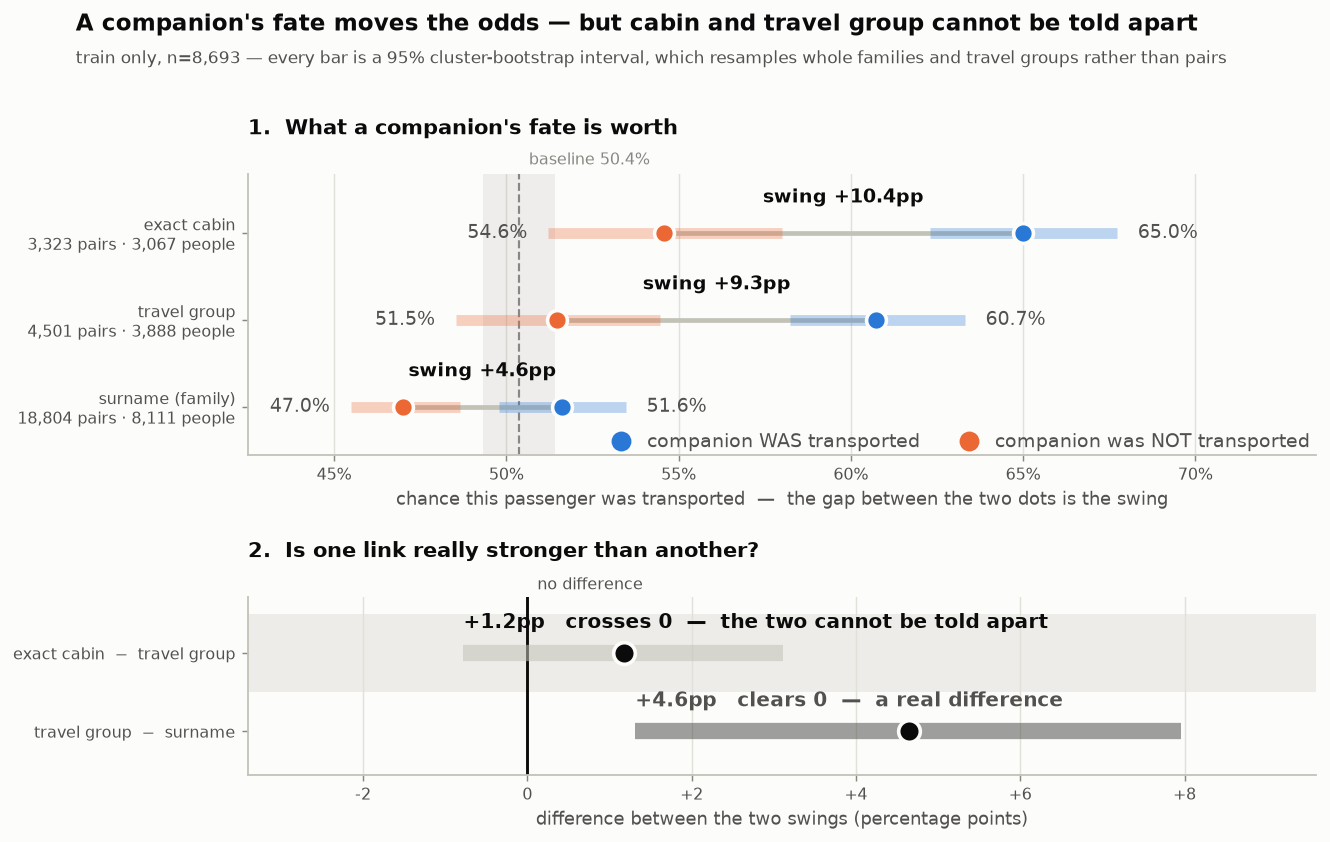

In [20]:
# ---- HIGHLIGHT CHART 3 -----------------------------------------------------
# Panel 1 is the six rates, each with the interval it earned. Panel 2 is the
# comparison the chart is actually about: a difference is only a ranking if its
# own interval clears zero.

UNITS = [("cabin", "exact cabin"), ("group", "travel group"),
         ("surname", "surname (family)")]
CONTRASTS = [("cabin_minus_group", "exact cabin  −  travel group"),
             ("group_minus_surname", "travel group  −  surname")]
counts = conc.set_index("unit")
LABEL = {"cabin": "exact cabin", "group": "travel group", "surname": "surname (family)"}

fig = plt.figure(figsize=(10.6, 6.0))
gs = fig.add_gridspec(2, 1, height_ratios=[3.0, 1.9], hspace=0.62)
ax1, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

# --- panel 1: the six rates, dot = estimate, faded bar = 95% interval -------
y = np.arange(len(UNITS))[::-1]
for yi, (key, label) in zip(y, UNITS):
    T, F = ci.loc[f"{key}_T"], ci.loc[f"{key}_F"]
    ax1.plot([F.point, T.point], [yi, yi], color=viz.BASELINE, lw=2.6,
             solid_capstyle="round", zorder=2)
    for row, colour in ((F, viz.SERIES[1]), (T, viz.SERIES[0])):
        ax1.plot([row.lo, row.hi], [yi, yi], color=colour, lw=6, alpha=0.30,
                 solid_capstyle="butt", zorder=3)
        ax1.plot([row.point], [yi], "o", ms=11, color=colour, mec=viz.SURFACE,
                 mew=2, zorder=5)
    ax1.text(F.lo - 0.006, yi, f"{F.point:.1%}", ha="right", va="center",
             fontsize=10.5, color=viz.INK_SECONDARY, zorder=6)
    ax1.text(T.hi + 0.006, yi, f"{T.point:.1%}", ha="left", va="center",
             fontsize=10.5, color=viz.INK_SECONDARY, zorder=6)
    ax1.text((F.point + T.point) / 2, yi + 0.30,
             f"swing {100 * (T.point - F.point):+.1f}pp", ha="center", va="bottom",
             fontsize=10.5, fontweight="bold", color=viz.INK, zorder=6)

# The one place a Wilson interval IS the right tool: 8,693 independent passengers.
base_lo, base_hi = viz.wilson(train[L.TARGET].sum(), len(train))
ax1.axvspan(base_lo, base_hi, color=viz.INK_MUTED, alpha=0.12, lw=0, zorder=1)
ax1.axvline(rate, color=viz.INK_MUTED, ls="--", lw=1.2, zorder=1)
ax1.text(rate, 1.02, f"  baseline {rate:.1%}", transform=ax1.get_xaxis_transform(),
         ha="left", va="bottom", fontsize=9, color=viz.INK_MUTED)

ax1.set_yticks(y, [f"{lab}\n{counts.loc[lab, 'pairs']:,} pairs · "
                   f"{counts.loc[lab, 'people']:,} people" for _, lab in UNITS])
ax1.set_ylim(-0.55, len(UNITS) - 0.32)
ax1.set_xlim(0.425, 0.735)
ax1.xaxis.set_major_formatter(lambda v, p: f"{v:.0%}")
ax1.set_xlabel("chance this passenger was transported  —  "
               "the gap between the two dots is the swing")
viz.clean(ax1, which="x")
handles = [plt.Line2D([], [], marker="o", ls="", ms=10, color=viz.SERIES[0]),
           plt.Line2D([], [], marker="o", ls="", ms=10, color=viz.SERIES[1])]
ax1.legend(handles, ["companion WAS transported", "companion was NOT transported"],
           loc="lower right", ncols=2, fontsize=10.5, handletextpad=0.35,
           columnspacing=1.6, bbox_to_anchor=(1.005, -0.03), borderaxespad=0.2)
ax1.set_title("1.  What a companion's fate is worth", loc="left", fontsize=11.5,
              color=viz.INK, pad=22)

# --- panel 2: the two comparisons, against a zero rule ----------------------
y2 = np.arange(len(CONTRASTS))[::-1]
ax2.axhspan(0.5, 1.5, color=viz.GRID, alpha=0.55, lw=0, zorder=0)
ax2.axvline(0, color=viz.INK, lw=1.6, zorder=2)
ax2.text(0, 1.02, "  no difference", transform=ax2.get_xaxis_transform(),
         ha="left", va="bottom", fontsize=9, color=viz.INK_SECONDARY)
for yi, (key, label) in zip(y2, CONTRASTS):
    r = ci.loc[key]
    crosses = r.lo < 0 < r.hi
    ax2.plot([100 * r.lo, 100 * r.hi], [yi, yi],
             color=viz.BASELINE if crosses else viz.INK_SECONDARY, lw=9,
             alpha=0.55, solid_capstyle="butt", zorder=3)
    ax2.plot([100 * r.point], [yi], "o", ms=12, color=viz.INK, mec=viz.SURFACE,
             mew=2, zorder=5)
    verdict = ("crosses 0  —  the two cannot be told apart" if crosses
               else "clears 0  —  a real difference")
    ax2.text(100 * r.lo, yi + 0.26, f"{100 * r.point:+.1f}pp   {verdict}",
             ha="left", va="bottom", fontsize=11, fontweight="bold",
             color=viz.INK if crosses else viz.INK_SECONDARY, zorder=6)

ax2.set_yticks(y2, [lab for _, lab in CONTRASTS])
ax2.set_ylim(-0.55, len(CONTRASTS) - 0.28)
ax2.set_xlim(-3.4, 9.6)
ax2.set_xticks([-2, 0, 2, 4, 6, 8])
ax2.xaxis.set_major_formatter(lambda v, p: f"{v:+.0f}" if v else "0")
ax2.set_xlabel("difference between the two swings (percentage points)")
viz.clean(ax2, which="x")
ax2.set_title("2.  Is one link really stronger than another?", loc="left",
              fontsize=11.5, color=viz.INK, pad=22)

show(fig, "07_companion_fate",
     "A companion's fate moves the odds — but cabin and travel group "
     "cannot be told apart",
     f"train only, n={len(train):,} — every bar is a 95% cluster-bootstrap "
     "interval, which resamples whole families and travel groups rather than pairs")

### How to read this chart

**Panel 1** has one row per unit. The blue dot is "your companion *was* transported", the orange
dot is "your companion was *not*", and the faded bar behind each dot is its **95% interval** —
the range the number could plausibly have taken. The grey line joining the two dots is the
**swing**: how much a companion's fate moves your odds.

All three swings are real. In every row the blue interval and the orange interval stay clear of
each other, so in all three units a companion's fate genuinely tells you something. Against a
50.4% baseline, that is a lot to get from columns most people delete.

**Panel 2** answers the question panel 1 cannot: is one link actually *stronger* than another?
It plots the two differences directly, each with its own interval, against a line at zero.

- **exact cabin − travel group = +1.2pp, interval [−0.8, +3.1].** That interval contains zero.
  A difference whose interval contains zero is a difference this data cannot confirm exists. So
  we cannot say cabin beats group.
- **travel group − surname = +4.6pp, interval [+1.3, +8.0].** That interval clears zero
  comfortably. Group really is the stronger link of those two.

So the honest reading is: **group beats surname; cabin and group are a tie.** If you were about
to build a cabin-level feature *because* it looked strongest, that reason does not hold.

### This chart is a correction, and that is the point

An earlier version of this very chart showed the same three units as three pairs of bars in a
tidy ascending ladder — +4.6pp, +9.3pp, +10.4pp — with no uncertainty on it anywhere. Anyone
reading it would have concluded that sharing a cabin is the strongest link of the three. Two of
those three rungs were real. The top one was not, and the chart gave the reader no way to know.

Nothing about the data changed. The only thing that changed is that the uncertainty is now
drawn. That is the same lesson section 9 teaches about other people's numbers, applied to this
notebook's own work — which is where it is easiest to skip.

> **The habit, again:** two numbers being different is not the same as two numbers being
> distinguishable. Before you rank things, plot the *difference* and check whether its interval
> clears zero. Ranking from the point estimates alone is how a ladder gets built out of noise.

### Where these intervals come from, and the one cross-check

The chart resamples connected family-and-group components, because surnames span travel groups.
`src/02_groups.py` runs the same bootstrap over travel groups alone and logs it at
`output/02_groups.log:47-56` (4,000 replicates, seed 0). The two agree:

| swing | point | this chart (components) | `02_groups.log` (travel groups) |
|---|---:|---:|---:|
| surname | +4.6pp | [+2.8, +6.5] | not run |
| travel group | +9.3pp | [+5.8, +12.9] | [+5.7, +12.8] |
| exact cabin | +10.4pp | [+6.4, +14.6] | [+6.5, +14.5] |
| **cabin − group** | **+1.2pp** | **[−0.8, +3.1]** | **[−0.8, +3.2]** |
| **group − surname** | **+4.6pp** | **[+1.3, +8.0]** | not run |

Two different choices of resampling unit landing within a fifth of a percentage point of each
other is the kind of agreement that makes a number worth quoting. `FINDINGS.md` records the
travel-group version.

### The check that makes this trustworthy

There is a subtle problem with counting pairs: a group of 10 people contributes 45 pairs, while
a group of 2 contributes 1. Large groups therefore dominate the average, and if large groups
behave unusually the whole result could be an artefact of that rather than a real effect.

`FINDINGS.md` records the test for this: the analysis was re-run on **size-2 units only**, where
every unit contributes exactly one pair and no group can dominate. The effect got **stronger**,
not weaker — the cabin swing rose to +13.8pp and the group swing to +10.3pp.

That is what turns an interesting number into a finding you can rely on.

> **The habit:** when a result depends on how you counted, find a way to count differently and
> check it survives. If it does, you have something. If it does not, you nearly shipped a bug.

### One caution on interpretation

Cabin-mates are mostly *also* groupmates, and they are also the closest social tie. So this
chart cannot cleanly separate "being in the same place" from "being related to each other". Read
it as a pattern that is definitely there, not as a proven mechanism.

## 8. The rest of the findings, briefly

The three highlights are the ideas worth internalising. The dataset has nine more findings that
are worth knowing but do not each need a full lesson. The charts below were produced by the
scripts in `src/` — the full write-up for every one of them is in `FINDINGS.md`.

### 8a. Travelling alone costs you 11 points

55% of passengers travel solo. They were transported at **45.2%**; anyone in a group, at
**56.7%**. The rate climbs to a peak at group size 4 and then falls back — but the larger sizes
have few passengers, so treat the solo-versus-grouped split as the finding and the exact shape
of the curve as decoration.

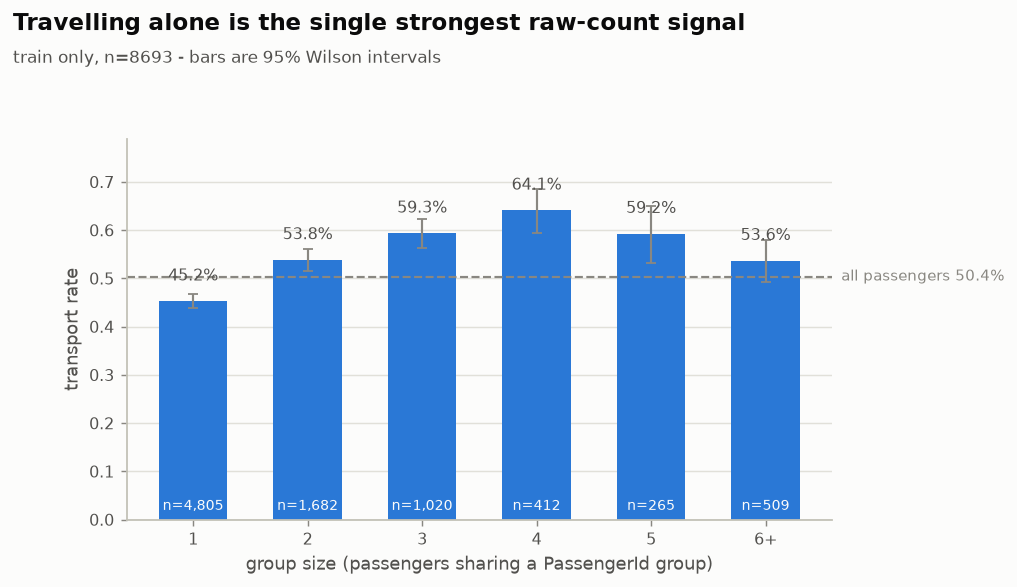

In [21]:
display(Image(str(ROOT / "figures" / "02_rate_by_groupsize.png")))

### 8b. Some columns are perfectly constant within a group — which turns guessing into lookup

`HomePlanet` is the same for every member of a travel group. Not *usually* the same —
**always**, across the **2,076 groups where the rule could actually have been broken**, with zero
exceptions. The same holds within a surname (2,185 testable of 2,198 multi-member surnames),
and `Side` (port or starboard) is also perfectly constant within a group (2,068 testable of the
same 2,135). Every one of those pairs of numbers is printed by the cell below.

That phrase "could actually have been broken" is the interesting part, and the cell below prints
both numbers so you can see the difference. There are 2,135 multi-member travel groups in
train+test. But a two-person group whose second member has a **missing** `HomePlanet` has only
one recorded value, so it can never show two different values — it scores as "constant" without
ever having been a test of anything. 59 of the groups are like that for `HomePlanet`. Counting
them would pad the denominator with easy cases.

So the 100% is measured on the 2,076 groups that had a genuine chance to break it. That is a
*stronger* claim than 100% of 2,135 would have been, not a weaker one.

`Deck` is not constant (67.5%), and neither is `Destination` (48.5%) or `CryoSleep` (40.7%).

This matters for the missing-data problem in section 3. A missing `HomePlanet` is not a gap to
be filled with the most common value — it is a **lookup**. Find anyone with the same surname and
copy their value across.

In [22]:
for key, attr in [("Group", "HomePlanet"), ("Surname", "HomePlanet"), ("Group", "Side")]:
    share, tested, multi = groups_mod.constancy(combined, key, attr)
    print(f"{attr:11s} constant within {key:8s}: {share:.1%}  "
          f"(across {tested:,} testable units, out of {multi:,} multi-member ones)")
print()
print("testable = at least TWO members have the value recorded, so the unit")
print("           was genuinely able to show two different values.")
print()
for key, attr in [("Surname", "HomePlanet"), ("Group", "HomePlanet")]:
    missing, fillable = groups_mod.recoverable(combined, key, attr)
    print(f"missing {attr} with a known {key:8s}: {missing:4d} -> recoverable: "
          f"{fillable:4d} ({fillable / missing:.1%})")

HomePlanet  constant within Group   : 100.0%  (across 2,076 testable units, out of 2,135 multi-member ones)
HomePlanet  constant within Surname : 100.0%  (across 2,185 testable units, out of 2,198 multi-member ones)
Side        constant within Group   : 100.0%  (across 2,068 testable units, out of 2,135 multi-member ones)

testable = at least TWO members have the value recorded, so the unit
           was genuinely able to show two different values.

missing HomePlanet with a known Surname :  278 -> recoverable:  271 (97.5%)
missing HomePlanet with a known Group   :  288 -> recoverable:  131 (45.5%)


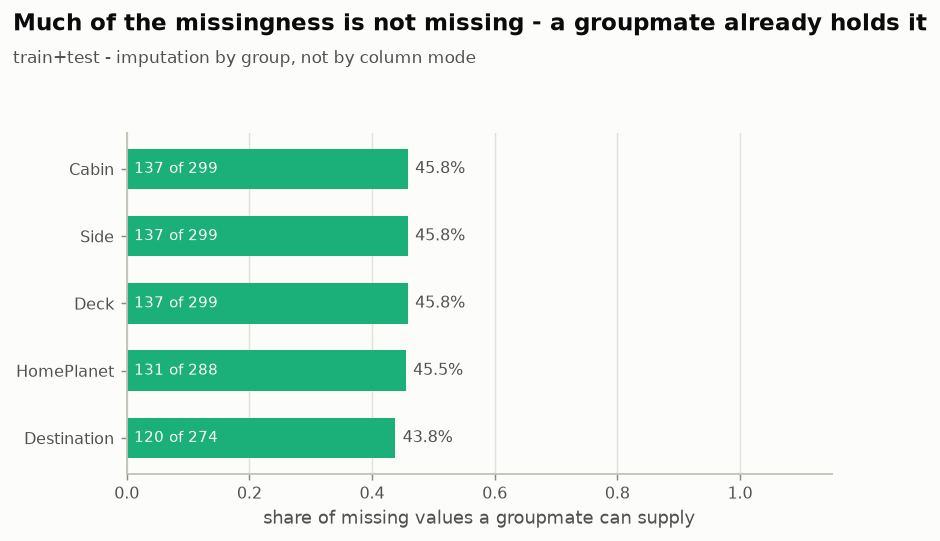

In [23]:
display(Image(str(ROOT / "figures" / "02_recoverable_missing.png")))

### 8c. Nobody under 13 spends a single credit — and the switch flips exactly at 13

Remember the `Age == 0` question from section 2? Here is the answer, plus a sharp discrete rule.

In [24]:
# Is Age == 0 a real infant, or a code for "missing"?
print(f"rows with Age == 0        : {(combined['Age'] == 0).sum()}")
print(f"rows with Age missing     : {combined['Age'].isna().sum()}")
print("--> Age has its own separate NaNs, so 0 is NOT a missing-value code.")
print("    Those are genuine infants.")
print()

kids = combined[combined["Age"] < 13]
spent_kids = (kids[L.SPEND_COLS].fillna(0) > 0).any(axis=1).sum()
print(f"passengers aged 0-12      : {len(kids):,}")
print(f"...with any nonzero charge: {spent_kids}")
print()
at13 = combined[combined["Age"] == 13]
print(f"passengers aged exactly 13: {len(at13)}")
print(f"...with any nonzero charge: {(at13[L.SPEND_COLS].fillna(0) > 0).any(axis=1).mean():.0%}")

rows with Age == 0        : 260
rows with Age missing     : 270
--> Age has its own separate NaNs, so 0 is NOT a missing-value code.
    Those are genuine infants.

passengers aged 0-12      : 1,157
...with any nonzero charge: 0

passengers aged exactly 13: 219
...with any nonzero charge: 53%


A hard switch at exactly 13 — another rule of the data generator, not a smooth trend.

(Those two counts, 1,157 children and 219 thirteen-year-olds, are from **train+test**. The
analysis scripts compute children on train alone, where there are 806 of them.)

Now, is the age effect real, or is it just that children are frozen more often? Section 6's habit
says: suspect a confounder, stratify, look. Among **awake passengers only** (train), under-13s
were transported at 68.2% versus 30.5% for awake adults — a gap that is *wider* than the
unstratified one, so the effect clearly survives CryoSleep.

But here is the part that is easy to miss, and it is the real lesson of this section: **one
stratification is not a guarantee that you are done.** Section 6 also established that *spending
money* is worth about −15pp on its own. So ask the habit's question again about the comparison we
just made — what else is different between awake children and awake adults?


In [25]:
# What else is different between awake children and awake adults? Spending.
# Section 6 put spending at about -15pp on its own, so if the two groups differ
# on it, part of the "age" gap is really the spend channel.
# TRAIN only: rates need Transported, which test.csv does not have.
awake_tr = train[train["CryoSleep"] == False]
spends_nothing = awake_tr[L.SPEND_COLS].fillna(0).sum(axis=1) == 0
kids = awake_tr["Age"] < 13
adults = awake_tr["Age"] >= 18

print("frame = train only, awake passengers")
print(f"awake under-13s who spend nothing : {spends_nothing[kids].mean():.1%}")
print(f"awake adults    who spend nothing : {spends_nothing[adults].mean():.1%}")
print("--> so 'awake children vs awake adults' is also 'people who spend")
print("    nothing vs people who almost all spend'. Hold that constant too.")
print()

def rate_line(mask):
    s = awake_tr.loc[mask, L.TARGET]
    lo, hi = viz.wilson(s.sum(), len(s))
    return f"{s.mean():6.1%}  (n={len(s):5,})  95% CI [{lo:.1%}, {hi:.1%}]"

def gap(a, b):
    return awake_tr.loc[a, L.TARGET].mean() - awake_tr.loc[b, L.TARGET].mean()

print("awake only")
print(f"  children <13 : {rate_line(kids)}")
print(f"  adults  >=18 : {rate_line(adults)}")
print(f"  gap          : {gap(kids, adults):+.1%}")
print()
print("awake AND spent nothing")
print(f"  children <13 : {rate_line(kids & spends_nothing)}")
print(f"  adults  >=18 : {rate_line(adults & spends_nothing)}")
print(f"  gap          : {gap(kids & spends_nothing, adults & spends_nothing):+.1%}")


frame = train only, awake passengers
awake under-13s who spend nothing : 100.0%
awake adults    who spend nothing : 2.2%
--> so 'awake children vs awake adults' is also 'people who spend
    nothing vs people who almost all spend'. Hold that constant too.

awake only
  children <13 :  68.2%  (n=  406)  95% CI [63.5%, 72.6%]
  adults  >=18 :  30.5%  (n=4,576)  95% CI [29.1%, 31.8%]
  gap          : +37.8%

awake AND spent nothing
  children <13 :  68.2%  (n=  406)  95% CI [63.5%, 72.6%]
  adults  >=18 :  37.0%  (n=  100)  95% CI [28.2%, 46.8%]
  gap          : +31.2%


Every awake child spends nothing; only about 2% of awake adults do. So the published comparison
was partly *children who spend nothing* versus *adults who almost all spend* — and we already
know spending is worth about −15pp.

Holding spending constant as well, the age gap drops from **+37.8pp to about +31.2pp**. Roughly a
sixth of it was the spend channel rather than age.

**The age effect is still real and still large.** 68.2% on 406 children against 37.0% on 100
spend-nothing adults, with intervals that do not come close to overlapping — that is a genuine
finding, and the second stratification makes it a *cleaner* one. But note what would have happened
if we had stopped after the first one: we would have reported 37.8pp as "the age effect with the
confounder removed", when a confounder this notebook itself had already identified was still
sitting in it.

> **The habit, sharpened:** stratifying on the confounder you thought of first does not mean you
> are finished. Ask the question again about the comparison you just made. There is no bell that
> rings when the last confounder is gone — which is also why an EDA can support a conclusion but
> never quite prove one.


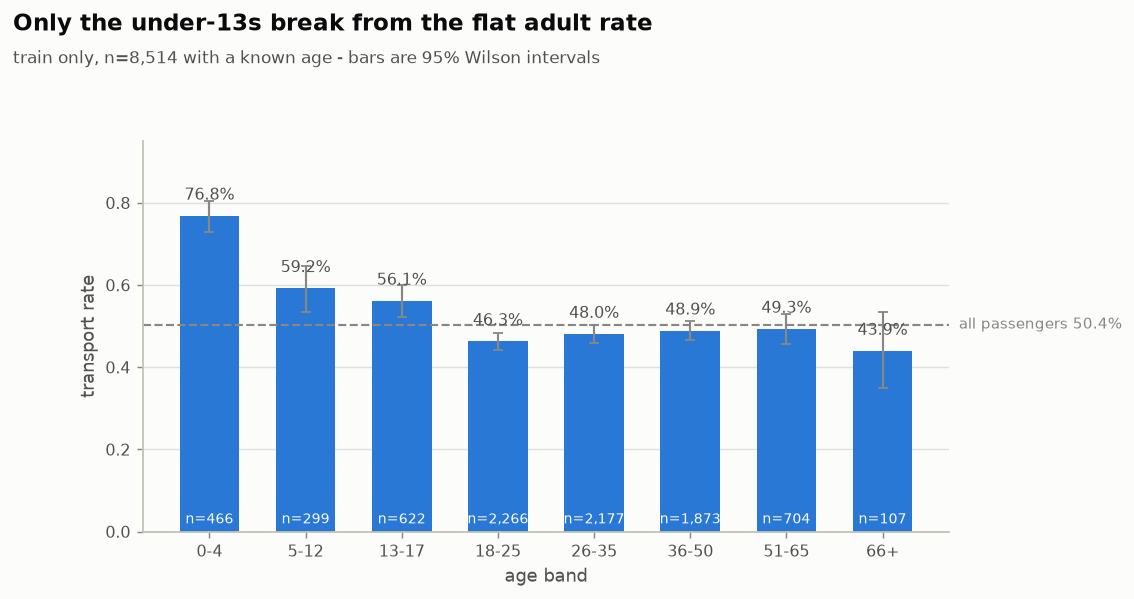

In [26]:
display(Image(str(ROOT / "figures" / "05_rate_by_age.png")))

### 8d. Starboard beats port on seven of the eight populated decks

Overall, starboard passengers were transported at 55.5% versus 45.1% for port — a 10.4pp gap on
8,494 train passengers. That overall gap is solid.

The per-deck story is the interesting one, because the obvious way to describe it is wrong in
three separate ways — and each one is a trap worth recognising.

**"All the decks" was seven of eight.** The chart draws A through G, and the direction does hold
on all seven. But the ship has an eighth populated deck, **T**, and it is missing from the chart
because `src/03_cabin.py` only draws cells with at least 30 passengers. On deck T the sign
*reverses*: 1 of 4 port passengers transported (25.0%) against 0 of 1 on starboard. Five people
is far too few to mean anything — which is exactly why it should be **named and excluded**, not
quietly dropped from a sentence containing the word "every". Excluding a tiny group is good
practice; forgetting to say you excluded it is not.

**Seven consistent signs, four that stand on their own.** Testing each deck's gap against its own
margin of error, only B, C, F and G clear it. A, D and E have gaps that could plausibly be zero
(their z values are 1.78, 1.37 and 0.89 — below the "about 2" bar from section 6). The honest
summary is "the sign is consistent on seven decks and individually convincing on four".

**And the decks are not independent.** This is the subtlest one. Calling them "seven independent
slices" makes them sound like seven separate experiments agreeing — but section 8e, two cells
down, is about to show you that deck is largely the *same fact* as home planet. Slices that share
an upstream cause are not independent confirmations, and counting them as if they were
overestimates how much you know.

(The per-deck z values are re-derived in the 2026-09-17 EDA audit report, not by `src/` — the
scripts compute each deck's rates but no test on the gap between them.)

> **The habit:** "it holds in every subgroup" is a strong-sounding claim, so check three things
> before you make it. Did you look at *every* subgroup, including the inconvenient ones? Does each
> one hold up on its own, or only the pooled total? And are the subgroups actually independent of
> each other?


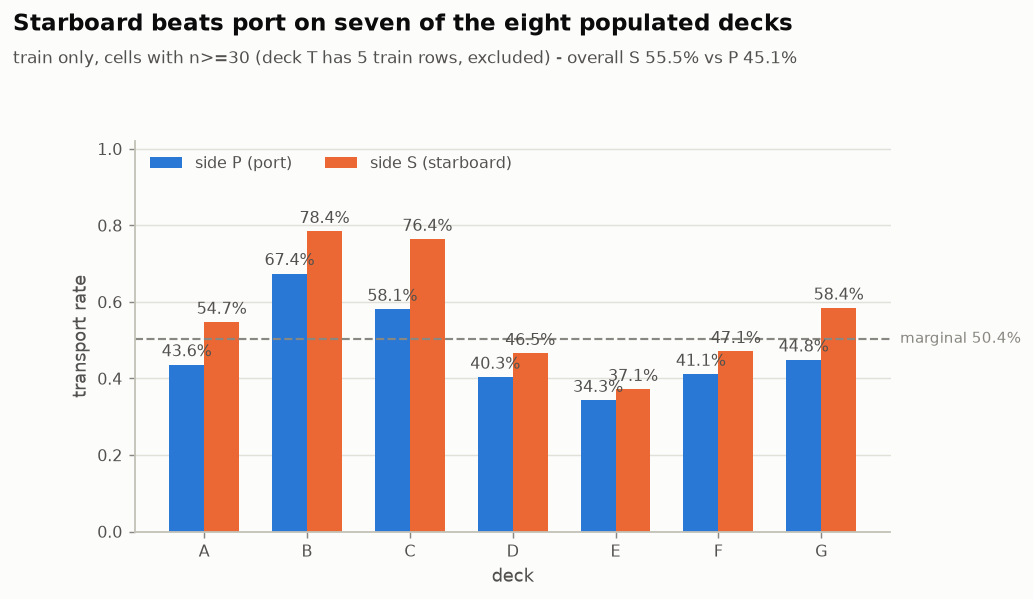

In [27]:
display(Image(str(ROOT / "figures" / "03_side_by_deck.png")))

### 8e. Deck and home planet are largely the same fact

Decks A, B and C are 100% Europa passengers. Deck G is 100% Earth. Only D, E and F are mixed.
(Deck T is all-Europa too, but on 10 passengers with a known planet — see 8d for why that is not
evidence.)

So "deck matters" and "home planet matters" are substantially **the same finding**, and you
should not count them as two independent pieces of evidence.

**Which means you can drop one — but which one?** The statistic quoted for this, Cramér's V of
0.75, cannot answer that, because it is **symmetric**: it measures how tangled two columns are
without saying which direction the knowledge runs. And here the direction is lopsided. Measured
properly, knowing someone's deck tells you **0.632** of what there is to know about their planet,
while knowing their planet tells you only **0.383** of what there is to know about their deck.

You can see why in the table above. Earth passengers only ever appear on decks E, F and G, and
Europa's only on A, B, C, D, E and T. So *deck B* pins the planet down to Europa immediately,
while *Europa* still leaves six decks open — and 8f will show those decks differ by more than
20 points.

**Deck carries strictly more information. If you drop one, drop `HomePlanet`.** That is the
actionable half of this finding, and it is the opposite of what you would guess from a write-up
that treats home planet as the primary variable.

(Cramér's V comes from `src/03_cabin.py` and `output/03_cabin.log`; the two directional figures
are re-derived in the 2026-09-17 EDA audit report, which is also where their arithmetic is shown.)

> **The habit:** a single symmetric number can tell you two things overlap. It cannot tell you
> which one to keep. If the answer matters, measure each direction separately.


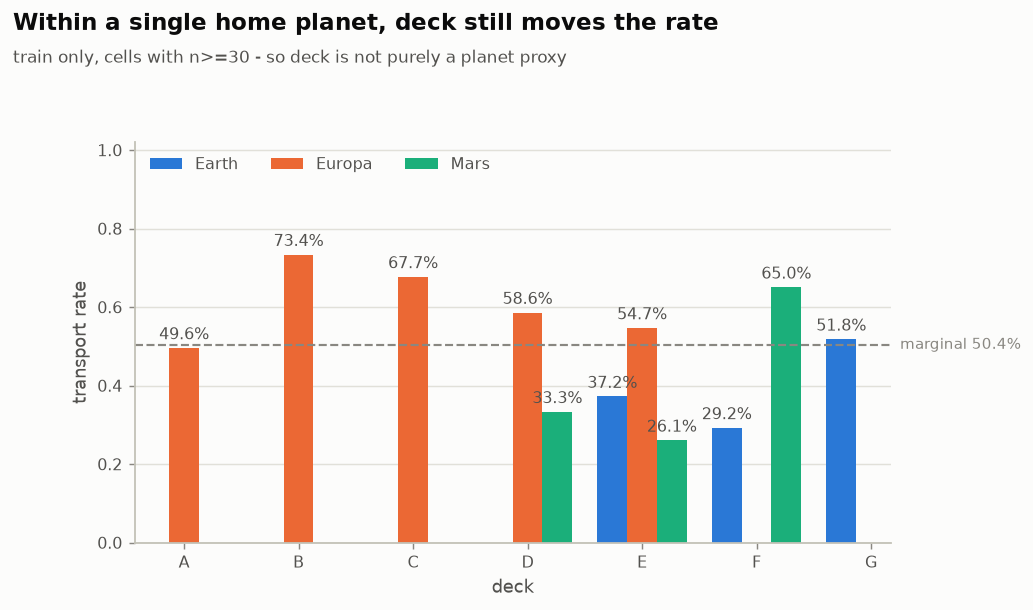

In [28]:
display(Image(str(ROOT / "figures" / "03_deck_within_homeplanet.png")))

### 8f. The cabin number is a position, not an identifier

Of 2,068 multi-member groups with a cabin, 1,395 (67.5%) occupy one identical cabin. The other
**673 are not next door — every single one of them spans more than one deck.** So a group either
shares a single cabin or is scattered across the ship; there is no "adjacent cabins" case at all.

That unanimous result is the entire argument, and it is worth appreciating how strong it is: since
*every* split group is on more than one deck, "booked next to each other" was never even a live
possibility.

An earlier version of this notebook added that "the median such group spans 254 cabin numbers",
which sounds like a measured distance and is not one. **Cabin numbers restart on every deck** —
deck A stops at 109, deck F runs to 1,894 — so subtracting an A cabin number from an F cabin
number subtracts two unrelated scales. Three of the 673 groups make the point perfectly: groups
0923 (`B/38/S` and `C/38/S`), 3494 (`B/112/P` and `D/112/P`) and 0006 (`G/0/S` and `F/2/S`) have
numeric spans of 0, 0 and 2 while being *decks apart*. A span of zero, and they are nowhere near
each other.

> **The habit:** before you subtract two numbers, check they are on the same scale. `CabinNum`
> looks like a coordinate and behaves like one *within* a deck — but only within a deck.

The number does carry real signal inside a single deck: sweeping along cabin numbers, the
transport rate moves by 0.363 on deck G and 0.176 on deck F. Both are far more movement than
random bin-to-bin wobble would produce — checked by shuffling the passengers between bins a few
thousand times and seeing how big a spread chance alone manages. (Deck C's 0.240 does *not* pass
that check, which is why the two examples quoted here are G and F. The shuffle test is re-derived
in the 2026-09-17 EDA audit report, not by `src/`.)


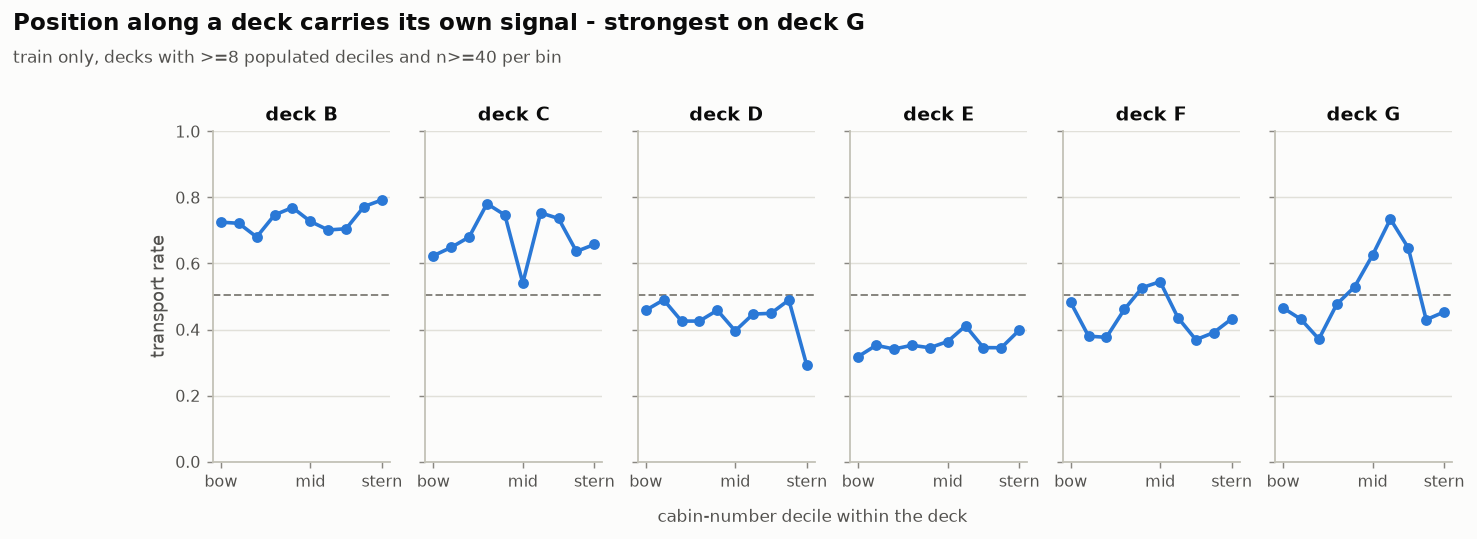

In [29]:
display(Image(str(ROOT / "figures" / "03_rate_by_cabinnum.png")))

### 8g. Where you came from beats where you were going

Home planet is the stronger of the two: **Europa 65.9%, Mars 52.3%, Earth 42.4%** (train).

But it is **not** clean, and by this point in the notebook you should suspect exactly why. Section
6's habit — *what else is different between these groups?* — applies here too, and the answer is
`CryoSleep`. The three planets freeze at very different rates, and freezing is the strongest
single predictor in the file.

| planet (train) | share frozen | frozen rate (n) | awake rate (n) |
|---|---:|---:|---:|
| Earth | 30.8% | 65.6% (1,382) | **32.1%** (3,106) |
| Europa | 43.9% | 98.9% (911) | **40.0%** (1,162) |
| Mars | 39.0% | 91.2% (669) | **27.7%** (1,047) |

Two things jump out of that table.

**About half the home-planet effect is really CryoSleep.** Unconditionally the planets span 23.5
points (42.4% to 65.9%). Among awake passengers only, they span **12.3 points** (27.7% to 40.0%).
Europa looked best partly because Europa freezes most.

**And the Earth/Mars ordering flips.** Unconditionally Mars (52.3%) is ahead of Earth (42.4%).
Among awake passengers, **Earth (32.1%) is ahead of Mars (27.7%)**. That is not a small
adjustment — it reverses which of the two you would call the better-off planet.

> **The lesson, for the third time and deliberately:** this is the same move as the `FoodCourt`
> flip in section 6 and the children-and-spending correction in 8c. A raw group difference is a
> mixture of the thing you named and everything that travels with it. Home planet is not a
> counter-example to that rule — it is another instance of it.

Destination is the weakest categorical, but it does not vanish once you control for origin —
Earth passengers heading to TRAPPIST-1e sit about 11 points below Earth passengers heading
anywhere else, on 3,101 rows. So "destination is just origin in disguise" overstates it.


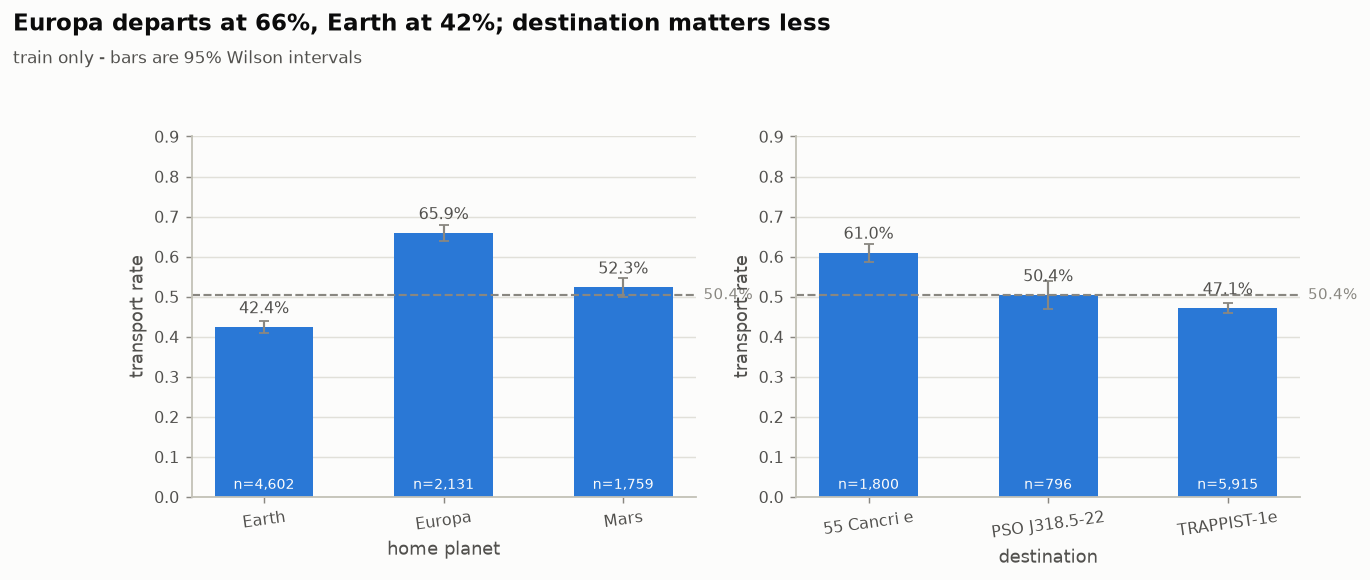

In [30]:
display(Image(str(ROOT / "figures" / "05_rate_by_origin_destination.png")))

## 9. Uncertainty — when is a difference real?

Every rate we have computed is an **estimate** from a sample, not a fact. A rate measured on
5,000 people is far more trustworthy than the same rate measured on 50.

A **confidence interval** puts that into numbers. The 95% interval is the range of true values
consistent with what we observed. Read it as: *"the real rate is probably somewhere in here."*

`src/viz.py` provides `wilson()`, which computes the Wilson score interval. It is used instead
of the textbook formula because the textbook one misbehaves badly when a rate is near 0% or 100%
or when the group is small — exactly the cases where you most need an honest answer.

The `VIP` column is the perfect demonstration.

In [31]:
vip = viz.rate_table(train[train["VIP"].notna()], "VIP")
vip["ci_width_pp"] = (vip["hi"] - vip["lo"]) * 100
vip[["n", "rate", "lo", "hi", "ci_width_pp"]].round(4)

,n,rate,lo,hi,ci_width_pp
VIP,,,,,
False,8291,0.5063,0.4956,0.5171,2.1519
True,199,0.3819,0.3172,0.4510,13.3800


In [32]:
# One denominator, stated. 273 VIPs out of the rows where VIP is actually
# recorded -- NOT out of all 12,970 rows, which would quietly assume that every
# missing VIP flag is a False.
n_vip = int((combined["VIP"] == True).sum())
n_known = int(combined["VIP"].notna().sum())
n_missing = int(combined["VIP"].isna().sum())
print(f"VIP recorded for      : {n_known:,} of {len(combined):,} passengers "
      f"({n_missing} missing)")
print(f"VIPs among those       : {n_vip} ({n_vip / n_known:.2%} of recorded)")
print(f"  for contrast, dividing by all {len(combined):,} rows would say "
      f"{n_vip / len(combined):.2%}")
print("  --> both round to '2.1%', which is how a sloppy denominator hides.")
print()
w_vip = (vip.loc[True, "hi"] - vip.loc[True, "lo"]) * 100
w_non = (vip.loc[False, "hi"] - vip.loc[False, "lo"]) * 100
print(f"interval width, VIP     : {w_vip:.1f}pp")
print(f"interval width, non-VIP : {w_non:.1f}pp")
print(f"--> the VIP interval is {w_vip / w_non:.0f}x wider, purely because there are so few VIPs")


VIP recorded for      : 12,674 of 12,970 passengers (296 missing)
VIPs among those       : 273 (2.15% of recorded)
  for contrast, dividing by all 12,970 rows would say 2.10%
  --> both round to '2.1%', which is how a sloppy denominator hides.

interval width, VIP     : 13.4pp
interval width, non-VIP : 2.2pp
--> the VIP interval is 6x wider, purely because there are so few VIPs


In [33]:
# The within-planet VIP split, with the intervals -- this is the uncertainty
# section, so the table below should not be quoting bare rates.
# TRAIN only (test.csv has no Transported), VIP recorded only.
vip_known = train[train["VIP"].notna() & train["HomePlanet"].notna()]
for planet in ["Europa", "Mars"]:
    sub_p = vip_known[vip_known["HomePlanet"] == planet]
    t = viz.rate_table(sub_p, "VIP")
    if True not in t.index:
        continue
    v, nv = t.loc[True], t.loc[False]
    print(f"{planet:7s} VIP     {v['rate']:.1%} (n={int(v['n']):,})  "
          f"95% CI [{v['lo']:.1%}, {v['hi']:.1%}]")
    print(f"{'':7s} non-VIP {nv['rate']:.1%} (n={int(nv['n']):,})  "
          f"95% CI [{nv['lo']:.1%}, {nv['hi']:.1%}]")
    print(f"{'':7s} gap     {v['rate'] - nv['rate']:+.1%}   "
          f"(VIP interval is {(v['hi'] - v['lo']) * 100:.0f}pp wide)")
    print()
print("Earth VIPs:", int((train["HomePlanet"].eq("Earth") & train["VIP"].eq(True)).sum()))


Europa  VIP     48.9% (n=131)  95% CI [40.5%, 57.3%]
        non-VIP 67.0% (n=1,958)  95% CI [64.9%, 69.1%]
        gap     -18.2%   (VIP interval is 17pp wide)

Mars    VIP     15.9% (n=63)  95% CI [8.9%, 26.8%]
        non-VIP 53.4% (n=1,653)  95% CI [51.0%, 55.8%]
        gap     -37.5%   (VIP interval is 18pp wide)



Earth VIPs: 0


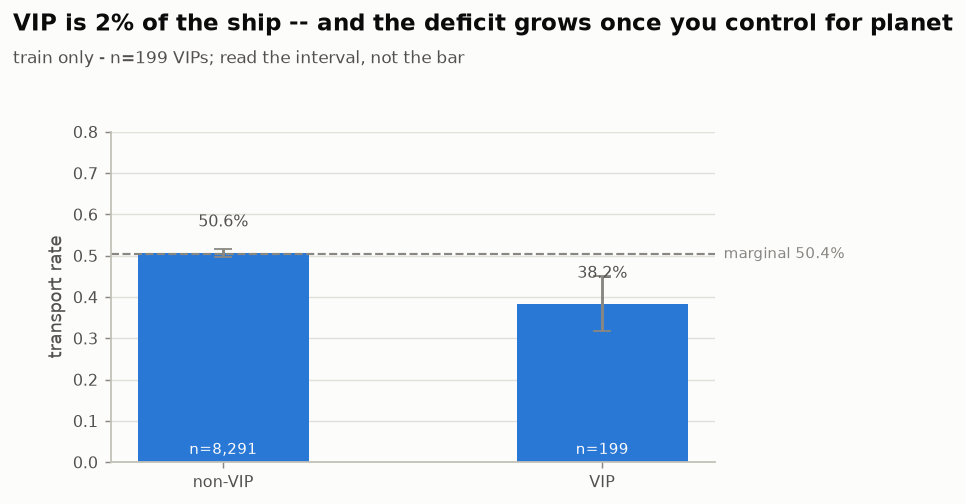

In [34]:
display(Image(str(ROOT / "figures" / "05_vip.png")))

The two intervals do not overlap, so the VIP deficit is real — VIPs were transported less often.
But the VIP interval is roughly six times wider, so we know that fact far less precisely.

There is also a nice twist here that rewards the section 6 habit. **Not one VIP came from
Earth** — they are 66% Europa, 34% Mars, and Europa has the highest transport rate of the three
planets. So the planet mix was *hiding* part of the VIP effect. Stratify by planet and the gap
gets *wider*, not narrower — and since this is the chapter about uncertainty, the table below
carries the intervals rather than only the rates:

| planet | VIP rate (n) | 95% interval | non-VIP rate (n) | 95% interval | gap |
|---|---:|---:|---:|---:|---:|
| Europa | 48.9% (n=131) | [40.5%, 57.3%] | 67.0% (n=1,958) | [64.9%, 69.1%] | **−18.2pp** |
| Mars | 15.9% (n=63) | [8.9%, 26.8%] | 53.4% (n=1,653) | [51.0%, 55.8%] | **−37.5pp** |

Against −12.4pp unconditionally. Same technique as the FoodCourt flip, opposite consequence:
there, controlling for the confounder *reversed* a finding; here it *strengthened* one. Both are
what "compare like with like" looks like in practice.

Now look at the two VIP intervals rather than the two VIP rates. Mars's is **18 points wide** —
63 people will not buy you a precise answer. The *gap* is still real, because [8.9%, 26.8%] and
[50.9%, 55.8%] are nowhere near each other. But −37.5pp against −18.2pp is not enough to say the
Mars deficit is genuinely deeper than the Europa one; those two intervals leave far too much room.

> **Rule of thumb:** always print `n` next to a rate — and once you have `n`, print the interval
> too. `n` tells you whether to be suspicious; the interval tells you how suspicious to be.


## 10. What this all means for building a model

You now know more about this dataset than most people who jump straight to fitting a classifier.
If you want to go on and build one, the analysis points to five concrete moves:

1. **Decode `PassengerId`, `Cabin` and `Name` before anything else.** That is where the signal
   is. Everything in sections 4 and 7 depends on this step.
2. **Fill missing values by lookup, not by column average.** Use group and surname for
   `HomePlanet` and `Side`; fill cryo-implied spending with 0; recover missing `CryoSleep` from
   nonzero spending.
3. **Keep the five spending columns separate.** Section 6 is the reason. Add a binary
   "spent anything at all" flag too — but for the right reason. It is often sold as "nearly as
   strong as `CryoSleep`" (78.7% for non-spenders versus 29.9% for spenders), and that comparison
   is close to circular: 83% of the non-spenders *are* the frozen passengers, because section 5
   showed frozen implies zero spend with no exceptions. The part that is genuinely new is what
   the flag does **among awake passengers**, where it separates **61.6%** (n=518, awake and spent
   nothing) from **29.9%** (n=4,921, awake and spent something). That is a real second signal;
   the 78.7% is mostly `CryoSleep` wearing a different hat.
4. **Add an `Age < 13` flag**, and group-level aggregates — group size, how much the rest of the
   group spent, whether the rest of the group was frozen. Section 7 says a companion's
   attributes predict yours. Build these at the **group** level: section 7 could not show that
   cabin beats group, so a cabin-level version is untested rather than better.
5. **Do not treat deck and home planet as two independent signals** — and if you drop one, drop
   `HomePlanet`, not `Deck`. Section 8e explains which way the information runs.

### One trap to know about before you split your data

There is a detail here that catches people out. **No travel group straddles the train/test
split** — Kaggle divided the data group-wise. So group features carry no leakage between the
two files.

But **surnames do straddle**: 1,536 of the 2,217 surnames in `train` also appear in `test`. A
surname-level feature therefore crosses the boundary. That is legitimate for this competition,
but if you build your own validation split by picking random rows, you will leak information
between your training and validation sets and your score will look better than it really is.

**Split by group, not by row.**

> **Leakage** is when information that would not be available at prediction time sneaks into
> training. It is the most common way a model looks brilliant in development and fails in
> production.

### Do not take my word for it — check the split yourself

Both claims above are checkable, and `src/load.py` ships the check. `verify()` re-derives the
structural facts this notebook has been relying on and prints them: that every `PassengerId`
parsed cleanly, how many travel groups span both files, and how many surnames do.

This is a habit worth copying. When an analysis rests on a structural assumption — "the split is
group-wise", "this id is unique", "these two files do not overlap" — write the check as code and
run it, rather than trusting a sentence in someone's write-up (including this one).

In [35]:
failures = L.verify(train, test, combined)
print()
print(f"parse failures: {failures}  <- must be 0 for anything above to hold")

STRUCTURAL DECODE VERIFICATION

rows: train=8693  test=4277  combined=12970
train columns: 27  test columns: 26
target present in train: True | in test: False

[1] PassengerId 'gggg_pp' parse failures: 0
    PassengerId unique: True
    PassengerId nulls : 0
    distinct groups   : 9280
    MemberNo range    : 1..8
    groups spanning BOTH train and test: 0 of 9280

[2] Cabin 'deck/num/side' parse failures (non-null Cabin): 0
    Cabin nulls: 299
    decks: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
    sides: ['P', 'S']
    CabinNum range: 0..1894

[3] Name 'first surname' parse failures (non-null Name): 0
    Name nulls: 294
    distinct surnames: 2406
    name token counts: {2: 12676}

[4] derived features
    GroupSize   range: 1..8
    SurnameSize range: 1.0..19.0
    TotalSpend  nulls: 0
    rows with a PARTIAL TotalSpend (1-4 services NaN): 1363
    rows with all 5 services NaN: 0

PASS: total parse failures = 0

parse failures: 0  <- must be 0 for anything above to hold


## Glossary

| Term | Plain meaning |
|---|---|
| **EDA** | Exploratory data analysis — looking at data to understand it before modelling |
| **Baseline / marginal rate** | How often the outcome happens overall (50.4% here). The number every result is judged against |
| **pp (percentage points)** | The arithmetic difference between two percentages. 50% → 65% is +15pp |
| **Feature engineering** | Building new, more useful columns out of the raw ones |
| **Confounding** | A hidden third variable that makes two things look related when the relationship is really about the third thing |
| **Stratify** | Split into groups where the confounder is constant, then compare inside a group |
| **Confidence interval** | The range of true values consistent with what you observed. Wide = imprecise |
| **Wilson interval** | A confidence interval for a proportion that stays sensible near 0%, near 100%, and on small groups |
| **z score** | How many standard errors an estimate sits from zero. Roughly, \|z\| > 2 means "probably not chance" |
| **Cramér's V** | How strongly two categorical columns are associated. 0 = unrelated, 1 = one determines the other |
| **Leakage** | Information reaching the model that it would not have in real use, inflating the score |
| **Deterministic rule** | A constraint that holds with zero exceptions, so it can fill missing values with certainty |

## Where to go next

- `FINDINGS.md` — the full expert write-up. Every claim in this notebook traces back to it.
- `output/*.log` — the raw numbers behind every figure.
- `src/0*.py` — the five analysis scripts. Run any of them with `.venv/bin/python src/01_overview.py`.

**A good next exercise:** pick one finding and try to break it. Re-run it on a different slice,
count it a different way, and see whether it survives. That is section 7's robustness check, and
it is the single most valuable habit in this whole notebook.